<div style="background-color:#111827;
padding:25px;
border-left:8px solid #F59E0B;
border-radius:10px;
margin-bottom:20px;">

<h1 style="color:white;
font-size:34px;
margin:0;">
Stress Testing de Cartera Crediticia
</h1>

<p style="color:#D1D5DB;
font-size:16px;
margin-top:10px;">
Probabilidad de Default bajo distintos escenarios macroeconómicos.
</p>

</div>

Este notebook es un Stress Testing de cartera crediticia usando el modelo logit para estimar cómo varía la Probabilidad de Default (PD) bajo distintos escenarios macroeconómicos, calculando la Pérdida Esperada (EL = PD × LGD × EAD).

El Stress Testing (o pruebas de estrés) en el sector bancario y financiero es un simulacro de catástrofes financieras. Consiste en evaluar qué tan resistente es un banco o una cartera de créditos ante escenarios económicos extremadamente adversos pero plausibles (como una recesión severa, una devaluación brusca, o un pico de inflación).  
El proceso traduce variables macroeconómicas en impactos financieros directos mediante modelos estadísticos.  
Las métricas clave que se buscan proyectar son:  

**PD** (Probability of Default): La probabilidad de que un cliente no pague su deuda.  
**LGD** (Loss Given Default): Qué porcentaje del crédito se pierde de forma irrecuperable si el cliente cae en default.  
**EAD** (Exposure at Default): El monto total expuesto al riesgo en el momento del incumplimiento.  

Con estos componentes se calcula la Pérdida Esperada ($EL$):$$EL = PD \times LGD \times EAD$$En un escenario de estrés, la $PD$ suele dispararse y el valor de las garantías (que reduce la $LGD$) suele caer. El objetivo final es medir si la entidad financiera mantiene los niveles de capital mínimo requeridos por sus reguladores para absorber esas pérdidas sin quebrar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning) # Filtrar mensajes de error de versiones.

In [2]:
df = pd.read_csv('pd_stress_testing.csv',index_col=False)

df = df.drop('Unnamed: 0', axis=1) # Borro la primer columna con el indice.

df.head(5)

,PD,saldo_actual,limite,LGD,EAD,EL
0,0.707421,19352,9909,0.45,19352.00,6160.502173
1,0.547952,47585,55478,0.45,53504.75,13193.122767
2,0.765016,36867,56360,0.45,51486.75,17724.684390
3,0.502764,30334,65555,0.45,56749.75,12839.276134
4,0.376505,8644,73978,0.45,57644.50,9766.561029


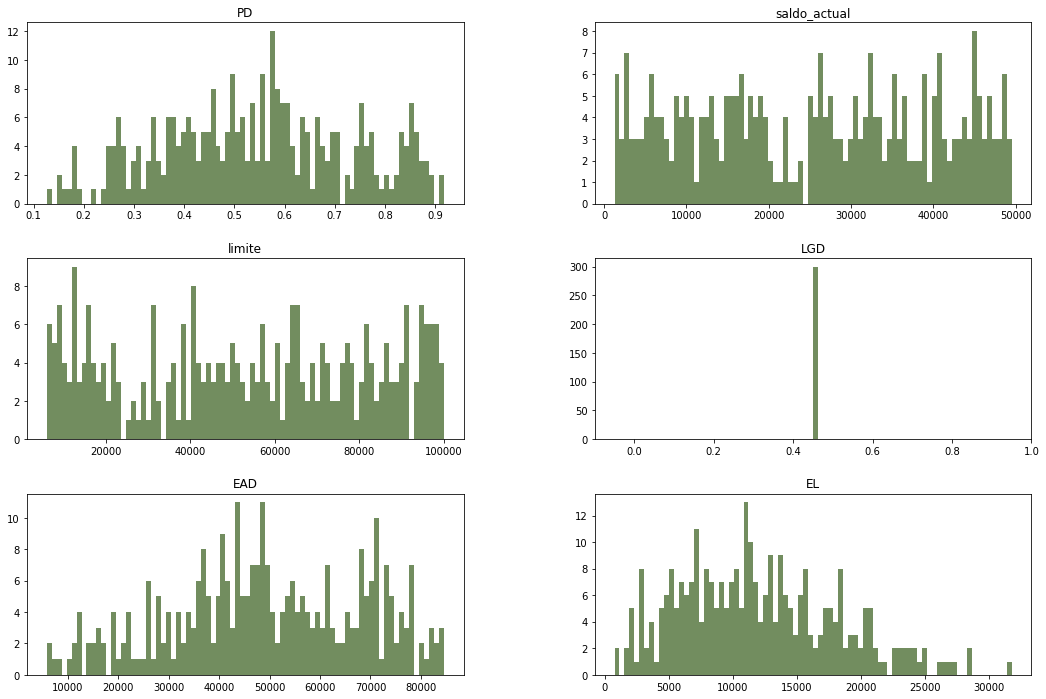

In [3]:
_ = df.hist(figsize=(18, 12), bins=80, color='#728D5F', grid=False)

In [4]:
df.dtypes

PD              float64
saldo_actual      int64
limite            int64
LGD             float64
EAD             float64
EL              float64
dtype: object

In [5]:
df.isnull().sum()

PD              0
saldo_actual    0
limite          0
LGD             0
EAD             0
EL              0
dtype: int64

In [6]:
escenarios = { # Defino diccionario con los escenarios a testear.
    'Base': {'pbi_var': 0.025, 'desempleo': 0.07}, # Es el escenario mas probable
    'Adverso': {'pbi_var': -0.015, 'desempleo': 0.10}, # Escenario moderado o intermedio.
    'Severo': {'pbi_var': -0.05, 'desempleo': 0.14} # Escenario mas extremo pero creible.
}

In [7]:
def calcular_pd_estresada(PD, pbi_var, desempleo_actual, desempleo_base=0.07):
    PD = np.clip(PD, 0.0001, 0.9999) # Para que nunca sean exactamente 0 ni 1, fuerza a mantenerse en un rango muy seguro, evita errores matematicos.
    
    logit_pd_base = np.log(PD / (1 - PD)) # Prepara los datos para que puedan recibir los impactos de la crisis económica de forma matemáticamente correcta y segura.
    
    # Estos son los coeficientes de sensibilidad.
    beta_pbi = -2.5      # Sensibilidad al PBI (la recesión aumenta el default)
    beta_desempleo = 3.0 # Sensibilidad al desempleo (a más desempleo aumenta el default)
    
    delta_desempleo = desempleo_actual - desempleo_base # Variación del desempleo respecto al estado base
    
    logit_pd_stress = logit_pd_base + (beta_pbi * pbi_var) + (beta_desempleo * delta_desempleo) # Aplicación del shock macroeconómico
        
    pd_stress = 1 / (1 + np.exp(-logit_pd_stress)) # Aplicar la función Sigmoide sobre el valor del Logit que ya fue golpeado por la crisis económica, transformándolo nuevamente en un porcentaje comprensible entre 0 y 100%.
    return pd_stress

In [8]:
for esc_nombre, variables in escenarios.items(): # Calcular la PD estresada para este escenario
    
    df[f'PD_{esc_nombre}'] = calcular_pd_estresada(
        df['PD'], 
        variables['pbi_var'], 
        variables['desempleo']
    )
    
    df[f'EL_{esc_nombre}'] = df[f'PD_{esc_nombre}'] * df['LGD'] * df['EAD'] # Calcular la Pérdida Esperada estresada


resumen_stress = pd.DataFrame({ # Ver el resumen del impacto en la cartera
    'Escenario': ['Base', 'Adverso', 'Severo'],
    'PD Promedio (%)': [df['PD'].mean()*100, df['PD_Adverso'].mean()*100, df['PD_Severo'].mean()*100],
    'Pérdida Esperada Total ($)': [df['EL_Base'].sum(), df['EL_Adverso'].sum(), df['EL_Severo'].sum()]
})
resumen_stress

,Escenario,PD Promedio (%),Pérdida Esperada Total ($)
0,Base,54.495786,3.509516e+06
1,Adverso,57.196915,3.778792e+06
2,Severo,61.512507,4.067449e+06


Esta ultima tabla, muestra cómo reacciona la cartera de crédito ante las tres situaciones económicas definida.  

En condiciones económicas normales (crecimiento moderado y desempleo controlado), la cartera ya tiene un riesgo inherentemente alto (más de la mitad de la probabilidad promedio está en riesgo de default). Entonces bajo este entorno se estima perder aproximadamente 3.5 millones de pesos. Este número de perdida, debería estar cubierto por las "Previsiones por Incobrabilidad" presentes en el balance.

Si el PBI cae un 1.5% y el desempleo sube al 10% (escenario adverso) el deterioro macroeconómico empuja a nuevos clientes al default. La pérdida aumenta cerca de un 7.6% en comparación con el escenario base.  

Ante una caída fuerte del PBI (-5%) y desempleo disparado (14%) que seria el escenario mas severo, la pérdida se eleva un 15.9% respecto al escenario normal superando perdidas por unos 4 millones.  

Lo que es muy llamativo de los resultados es que la PD Promedio Base ya es extremadamente alta (54.49%). En carteras bancarias tradicionales de consumo o comerciales la PD promedio suele rondar entre el 1% y el 10%. Una PD superior al 50% suele ser típica de:

- Carteras de microcréditos o sectores de muy bajos recursos (subprime).  
- Carteras que ya están en una etapa avanzada de mora o "recupero".

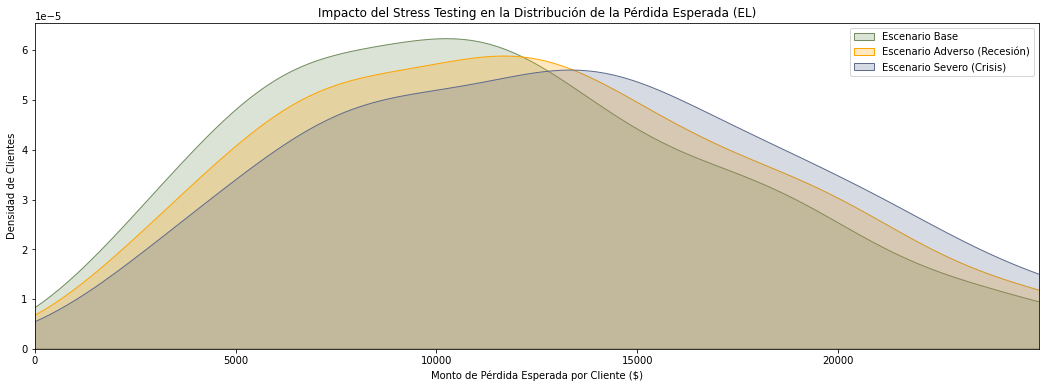

In [9]:
plt.figure(figsize=(18, 6))
sns.kdeplot(df['EL_Base'], label='Escenario Base', shade=True, color='#728D5F')
sns.kdeplot(df['EL_Adverso'], label='Escenario Adverso (Recesión)', shade=True, color='orange')
sns.kdeplot(df['EL_Severo'], label='Escenario Severo (Crisis)', shade=True, color='#5f6c8d')

plt.title('Impacto del Stress Testing en la Distribución de la Pérdida Esperada (EL)')
plt.xlabel('Monto de Pérdida Esperada por Cliente ($)')
plt.ylabel('Densidad de Clientes')
plt.xlim(0, df['EL_Severo'].quantile(0.95)) # Acotar al percentil 95 para mejor visualización
plt.legend()
plt.show()

El gráfico muestra tres distribuciones de densidad de la pérdida esperada individual por cliente, una por escenario.  
Forma general: las tres curvas tienen una forma similar (misma cartera, misma LGD/EAD) pero desplazadas hacia la derecha cuanto mayor es el estrés. Como el pico se achata y se ensancha, significa que el aplicar mas stress diferencia más a los clientes entre sí, los más riesgosos se alejan mucho más de la media.

In [10]:
df_sorted = df.nlargest(int(len(df)*0.1), 'EL_Severo') # Calcula la concentración de pérdidas esperadas severas (EL_Severo) en el 10% de los registros con mayor valor.
concentracion = df_sorted['EL_Severo'].sum() / df['EL_Severo'].sum()

In [11]:
df_sorted.head(10) # Top 10 del 10% de los mayores EL (perdida esperada) en configuración Severa.

,PD,saldo_actual,limite,LGD,EAD,EL,PD_Base,EL_Base,PD_Adverso,EL_Adverso,PD_Severo,EL_Severo
146,0.864427,30868,98670,0.45,81719.50,31788.232920,0.856934,31512.694531,0.878687,32312.635220,0.899126,33064.267495
235,0.785069,36400,94752,0.45,80164.00,28320.415343,0.774335,27933.208816,0.805801,29068.304394,0.836232,30166.056843
164,0.860571,5424,96406,0.45,73660.50,28525.543766,0.852901,28271.317010,0.875178,29009.732380,0.896139,29704.519053
101,0.799292,32184,90742,0.45,76102.50,27372.641003,0.789077,27022.841724,0.818968,28046.489138,0.847726,29031.317125
294,0.866578,7225,90194,0.45,69451.75,27083.406953,0.859185,26852.342843,0.880643,27522.990640,0.900790,28152.650302
13,0.774277,11404,96451,0.45,75189.25,26197.802580,0.763167,25821.891227,0.795780,26925.338089,0.827445,27996.721249
249,0.846628,42797,78370,0.45,69476.75,26469.444017,0.838336,26210.182819,0.862463,26964.501354,0.885279,27677.832308
112,0.669020,46555,95307,0.45,83119.00,25023.713580,0.655037,24500.711775,0.696620,26056.068442,0.738610,27626.624280
89,0.830275,24138,81649,0.45,67271.25,25134.137245,0.821285,24861.989926,0.847494,25655.382731,0.872426,26410.122176
96,0.762844,26613,86549,0.45,71565.00,24566.821830,0.751352,24196.727034,0.785133,25284.630329,0.818071,26345.378713


In [12]:
concentracion # El resultado x100 es el porcentaje, el 10% de clientes más riesgosos concentra el 19% de la pérdida esperada severa. El riesgo esta mas distribuido.

0.18872859191785446

In [13]:
print(f"El 10% de clientes más riesgosos concentra el {concentracion:.2%} de la pérdida esperada severa. El riesgo esta mas distribuido.")

El 10% de clientes más riesgosos concentra el 18.87% de la pérdida esperada severa. El riesgo esta mas distribuido.


## SIMULACION DE MONTECARLO - DISTRIBUCION DE PERDIDA DE LA CARTERA

In [14]:
# Escenario severo: shocks con incertidumbre explícita
MC_PARAMS = {
    'pbi_mean':    -0.050,  'pbi_std':    0.020, # PBI caida del 5%, pbi_std seria la volatilidad 2% de la media.
    'des_mean':     0.140,  'des_std':    0.020, # Media del desempleo 14%
    'des_base':     0.070, # Nivel normal del desempleo.
}
N_SIMS   = 10_000 # Cantidad de simulaciones.
SEED     = 42
CONF_VAR = [0.95, 0.99]  # Niveles de confianza para VaR (Value at Risk)/ CVaR (Conditional Value at Risk)

rng = np.random.default_rng(SEED) # Generador moderno de numeros aleatorios de numpy.

# ── Vectores fijos de la cartera ─────────────────────────────────────────────
pd_base = df['PD'].values
lgd     = df['LGD'].values
ead     = df['EAD'].values

# ── Loop Montecarlo ───────────────────────────────────────────────────────────
pbi_draws = rng.normal(MC_PARAMS['pbi_mean'], MC_PARAMS['pbi_std'], N_SIMS)
des_draws = rng.normal(MC_PARAMS['des_mean'], MC_PARAMS['des_std'], N_SIMS)

# np.clip evita desempleo negativo
des_draws = np.clip(des_draws, 0, 1)

el_portfolio = np.empty(N_SIMS)

for i in range(N_SIMS):
    pd_s = calcular_pd_estresada(pd_base, pbi_draws[i], des_draws[i],
                                 desempleo_base=MC_PARAMS['des_base'])
    el_portfolio[i] = (pd_s * lgd * ead).sum()

print(f"EL media simulada:  ${el_portfolio.mean():,.0f}")
print(f"EL mediana:         ${np.median(el_portfolio):,.0f}")
print(f"Desvío estándar:    ${el_portfolio.std():,.0f}")

EL media simulada:  $4,069,138
EL mediana:         $4,069,546
Desvío estándar:    $108,083


"EL media simulada": Es el Expected Loss (EL) promedio simulado. Quiere decir que si repito el escenario miles de veces la pérdida promedio sería aproximadamente 4 millones.  
"EL mediana": Es el Expected Loss (EL) medio. El valor que divide las simulaciones al medio. 50% seran superiores y el otro 50% inferiores.  
"Desvio Estandar": Cuanto fluctúan las pérdidas alrededor del promedio.

In [15]:
# ── VaR y CVaR ────────────────────────────────────────────────────────────────
resultados_riesgo = []
for conf in CONF_VAR:
    var   = np.percentile(el_portfolio, conf * 100)
    cvar  = el_portfolio[el_portfolio >= var].mean()
    resultados_riesgo.append({
        'Nivel confianza': f"{conf:.0%}",
        'VaR ($)':         round(var, 2),
        'CVaR ($)':        round(cvar, 2),
        'VaR / EAD (%)':   round(var  / df['EAD'].sum() * 100, 3),
        'CVaR / EAD (%)':  round(cvar / df['EAD'].sum() * 100, 3),
    })

pd.DataFrame(resultados_riesgo).set_index('Nivel confianza')

,VaR ($),CVaR ($),VaR / EAD (%),CVaR / EAD (%)
Nivel confianza,,,,
95%,4245839.85,4291343.78,28.663,28.970
99%,4319843.81,4354596.74,29.162,29.397


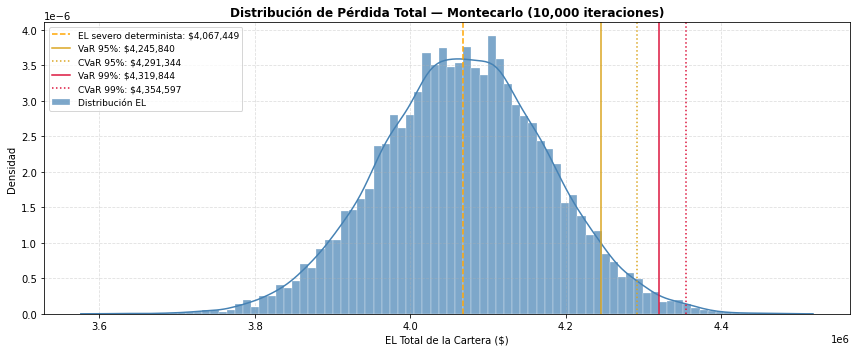

In [16]:
# ── Gráfico: distribución de EL total simulada ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(el_portfolio, bins=80, color='steelblue', alpha=0.7,
        edgecolor='white', linewidth=0.4, density=True, label='Distribución EL')
sns.kdeplot(el_portfolio, ax=ax, color='steelblue', linewidth=1.5)

# Línea EL determinista (escenario severo original)
el_det = df['EL_Severo'].sum()
ax.axvline(el_det, color='orange', linestyle='--', linewidth=1.5,
           label=f'EL severo determinista: ${el_det:,.0f}')

# VaR y CVaR
colores_var = ['goldenrod', 'crimson']
for (conf, res), color in zip(
        [(c, r) for c, r in zip(CONF_VAR, resultados_riesgo)], colores_var):
    ax.axvline(res['VaR ($)'], color=color, linestyle='-', linewidth=1.5,
               label=f"VaR {conf:.0%}: ${res['VaR ($)']:,.0f}")
    ax.axvline(res['CVaR ($)'], color=color, linestyle=':', linewidth=1.5,
               label=f"CVaR {conf:.0%}: ${res['CVaR ($)']:,.0f}")

ax.set_title(f'Distribución de Pérdida Total — Montecarlo ({N_SIMS:,} iteraciones)',
             fontweight='bold')
ax.set_xlabel('EL Total de la Cartera ($)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [17]:
# ── Comparación: determinista vs Montecarlo ───────────────────────────────────
comp = pd.DataFrame({
    'Métrica': ['EL Base (det.)', 'EL Adverso (det.)', 'EL Severo (det.)',
                'EL MC media', 'EL MC mediana',
                f'VaR {CONF_VAR[0]:.0%}', f'VaR {CONF_VAR[1]:.0%}',
                f'CVaR {CONF_VAR[0]:.0%}', f'CVaR {CONF_VAR[1]:.0%}'],
    'EL ($)': [
        df['EL_Base'].sum(), df['EL_Adverso'].sum(), df['EL_Severo'].sum(),
        el_portfolio.mean(), np.median(el_portfolio),
        resultados_riesgo[0]['VaR ($)'], resultados_riesgo[1]['VaR ($)'],
        resultados_riesgo[0]['CVaR ($)'], resultados_riesgo[1]['CVaR ($)'],
    ]
})
comp['EL / EAD (%)'] = (comp['EL ($)'] / df['EAD'].sum() * 100).round(3)
comp.set_index('Métrica')

,EL ($),EL / EAD (%)
Métrica,,
EL Base (det.),3.509516e+06,23.692
EL Adverso (det.),3.778792e+06,25.510
EL Severo (det.),4.067449e+06,27.458
EL MC media,4.069138e+06,27.470
EL MC mediana,4.069546e+06,27.472
VaR 95%,4.245840e+06,28.663
VaR 99%,4.319844e+06,29.162
CVaR 95%,4.291344e+06,28.970
CVaR 99%,4.354597e+06,29.397


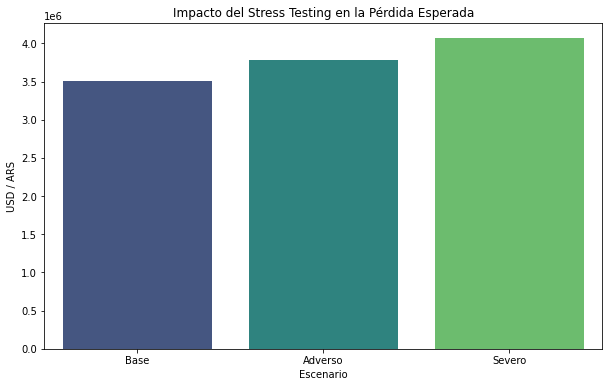

In [18]:
import seaborn as sns

# Transformar para graficar fácilmente
plot_data = resumen_stress.melt(id_vars='Escenario', value_vars='Pérdida Esperada Total ($)')

plt.figure(figsize=(10,6))
sns.barplot(data=plot_data, x='Escenario', y='value', palette='viridis')
plt.title('Impacto del Stress Testing en la Pérdida Esperada')
plt.ylabel('USD / ARS')
plt.show()

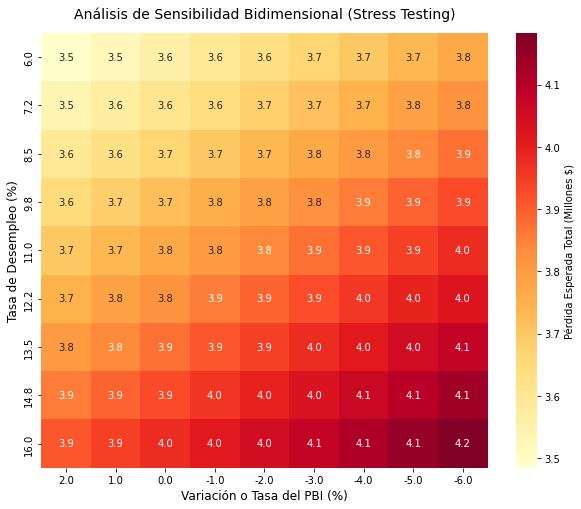

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir los rangos de estrés que queremos evaluar
rangos_pbi = np.round(np.linspace(2.0, -6.0, 9), 1)       # Del +2% al -6% de crecimiento
rangos_desempleo = np.round(np.linspace(6.0, 16.0, 9), 1)  # Del 6% al 16% de desempleo

# 2. Crear una matriz vacía para guardar las Pérdidas Esperadas (EL)
matriz_el = np.zeros((len(rangos_desempleo), len(rangos_pbi)))

# Supongamos que tienes tus funciones del notebook y los datos cargados en 'df'
# Iteramos sobre cada combinación para simular el impacto
for i, desp in enumerate(rangos_desempleo):
    for j, pbi in enumerate(rangos_pbi):
        
        # Simulamos la PD estresada para esta combinación específica
        # (Ajusta los betas según los que definiste en tu modelo)
        logit_estresado = np.log(df['PD'] / (1 - df['PD'])) + (-2.5)*(pbi/100) + 3.0*(desp - 7.0)/100
        pd_estresada = 1 / (1 + np.exp(-logit_estresado))
        
        # Calculamos la nueva Pérdida Esperada total del portafolio
        el_total = (pd_estresada * df['LGD'] * df['EAD']).sum()
        
        # Guardamos el resultado en millones (para que el gráfico sea legible)
        matriz_el[i, j] = el_total / 1_000_000

# 3. Convertir a DataFrame para graficar fácilmente con Seaborn
df_heatmap = pd.DataFrame(matriz_el, index=rangos_desempleo, columns=rangos_pbi)

# 4. Diseñar el Heatmap gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_heatmap, 
    annot=True,          # Muestra el número exacto en cada celda
    fmt=".1f",           # Formato con un decimal
    cmap="YlOrRd",       # Paleta de colores de Amarillo (bajo) a Rojo (alto)
    cbar_kws={'label': 'Pérdida Esperada Total (Millones $)'}
)

plt.title('Análisis de Sensibilidad Bidimensional (Stress Testing)', fontsize=14, pad=15)
plt.xlabel('Variación o Tasa del PBI (%)', fontsize=12)
plt.ylabel('Tasa de Desempleo (%)', fontsize=12)
plt.show()